# Chapter 2 - Regression - Part I

Scenario: a real-estate company wants to predict a home's sale price using information available before the sale.


## 0. Import libraries and dataset

Load the libraries and the housing dataset that will be used throughout the notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TODO: define the path where housing_regression_dataset.csv is stored.
DATASET_PATH = Path("housing_regression_dataset.csv")
df = pd.read_csv(DATASET_PATH)

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

In [3]:
df.head()

,house_id,living_area_m2,usable_area_m2,living_area_ft2,rooms,age_years,distance_center_km,noise_feature,final_notary_fee_k_eur,final_agent_commission_k_eur,final_price_per_m2_k_eur,sale_price_k_eur
0,H0001,181.57,172.04,1954.401323,6,19.0,15.45,0.125730,3.600,9.764,1.6806,305.14
1,H0002,124.61,124.05,1341.289579,4,53.4,6.75,-0.132105,2.891,7.673,1.9242,239.77
2,H0003,195.96,180.25,2109.293844,6,35.6,15.82,0.640423,3.458,9.988,1.5929,312.14
3,H0004,168.55,157.46,1814.255345,6,7.6,8.35,0.104900,3.205,8.355,1.5491,261.10
4,H0005,66.01,65.16,710.525039,2,8.6,24.42,-0.535669,0.762,2.032,0.9621,63.51


## 1. Describe and visualize the dataset

Explore the variables, their distributions and the relationships that may be useful for predicting sale price.

The company wants to make the prediction **before the sale is completed**.

Some columns describe the home before the transaction; other columns are recorded or calculated only after the final sale.

| Column | Meaning |
|---|---|
| `house_id` | Internal identifier of the transaction |
| `living_area_m2` | Living area in square metres |
| `usable_area_m2` | Alternative measure of usable area |
| `living_area_ft2` | Living area converted exactly to square feet |
| `rooms` | Number of rooms |
| `age_years` | Age of the property |
| `distance_center_km` | Distance to the city centre |
| `noise_feature` | Artificial irrelevant variable, available before the sale |
| `final_notary_fee_k_eur` | Final notary fee recorded after the deed is signed |
| `final_agent_commission_k_eur` | Final agency commission calculated from the completed transaction amount |
| `final_price_per_m2_k_eur` | Final sale price per m², calculated after the transaction |
| `sale_price_k_eur` | Final sale price; this is the target |

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
house_id,260,260,H0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
living_area_m2,260.0,NaN,NaN,NaN,134.219462,48.387715,51.25,90.115,133.24,177.0275,218.7
usable_area_m2,260.0,NaN,NaN,NaN,126.223038,45.606355,45.76,85.9125,125.15,164.17,210.49
living_area_ft2,260.0,NaN,NaN,NaN,1444.724862,520.84052,551.649875,969.988848,1434.182036,1905.506307,2354.06493
rooms,260.0,NaN,NaN,NaN,4.169231,1.658666,1.0,3.0,4.0,6.0,8.0
age_years,260.0,NaN,NaN,NaN,30.470385,17.459429,0.1,15.05,30.7,45.125,59.6
distance_center_km,260.0,NaN,NaN,NaN,12.677423,7.130733,0.51,6.27,12.455,18.9875,24.99
noise_feature,260.0,NaN,NaN,NaN,0.005751,1.018646,-3.106337,-0.662161,-0.012724,0.703555,3.066037
final_notary_fee_k_eur,260.0,NaN,NaN,NaN,2.565081,1.133897,-0.058,1.61025,2.626,3.45275,5.035
final_agent_commission_k_eur,260.0,NaN,NaN,NaN,6.894242,2.992741,0.555,4.379,7.0305,9.3325,13.359


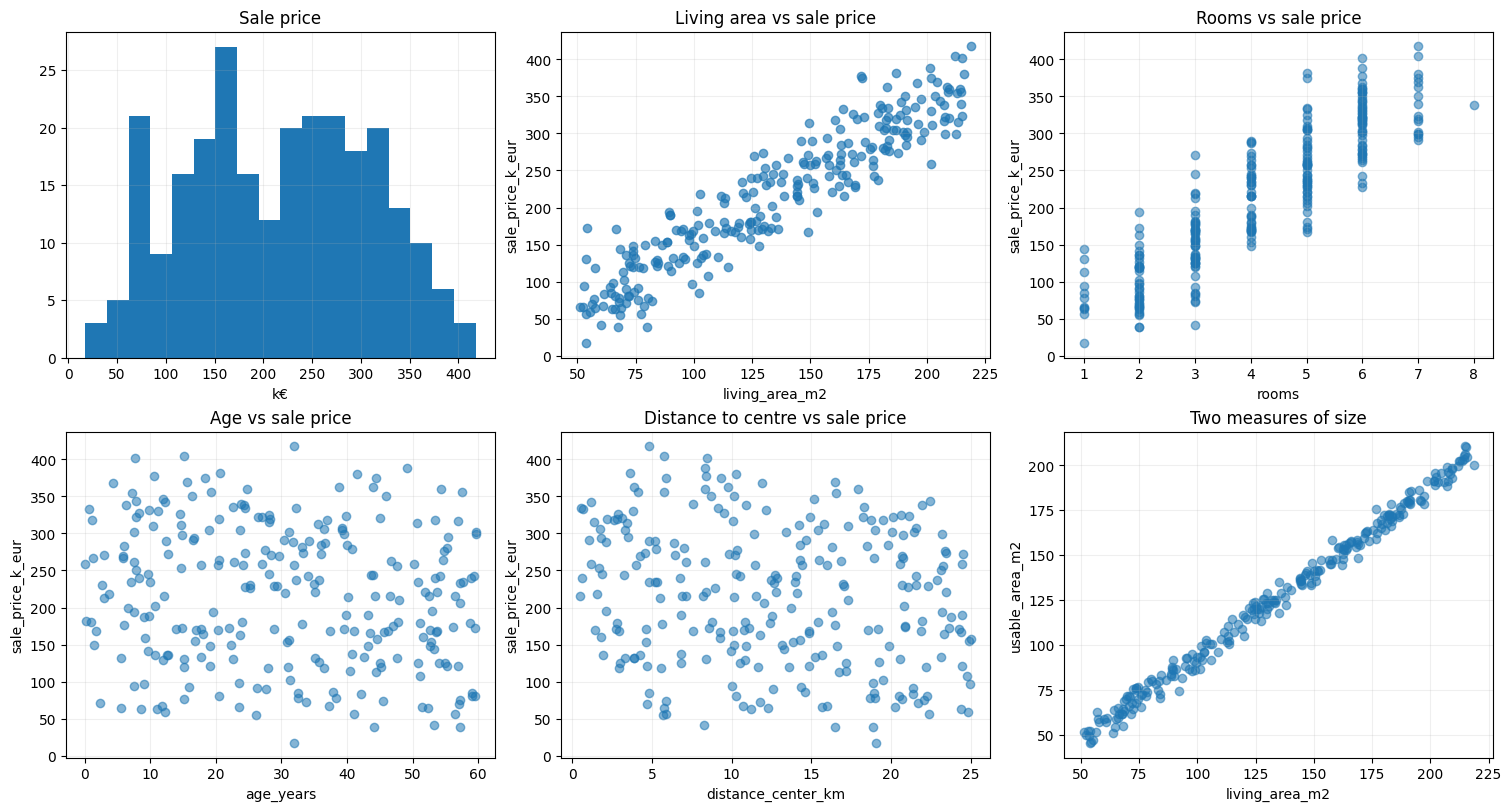

In [4]:
display(df.describe(include="all").T)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

axes[0, 0].hist(df["sale_price_k_eur"], bins=18)
axes[0, 0].set_title("Sale price")
axes[0, 0].set_xlabel("k€")

axes[0, 1].scatter(df["living_area_m2"], df["sale_price_k_eur"], alpha=0.65)
axes[0, 1].set_title("Living area vs sale price")
axes[0, 1].set_xlabel("living_area_m2")
axes[0, 1].set_ylabel("sale_price_k_eur")

axes[0, 2].scatter(df["rooms"], df["sale_price_k_eur"], alpha=0.55)
axes[0, 2].set_title("Rooms vs sale price")
axes[0, 2].set_xlabel("rooms")
axes[0, 2].set_ylabel("sale_price_k_eur")

axes[1, 0].scatter(df["age_years"], df["sale_price_k_eur"], alpha=0.55)
axes[1, 0].set_title("Age vs sale price")
axes[1, 0].set_xlabel("age_years")
axes[1, 0].set_ylabel("sale_price_k_eur")

axes[1, 1].scatter(df["distance_center_km"], df["sale_price_k_eur"], alpha=0.55)
axes[1, 1].set_title("Distance to centre vs sale price")
axes[1, 1].set_xlabel("distance_center_km")
axes[1, 1].set_ylabel("sale_price_k_eur")

axes[1, 2].scatter(df["living_area_m2"], df["usable_area_m2"], alpha=0.55)
axes[1, 2].set_title("Two measures of size")
axes[1, 2].set_xlabel("living_area_m2")
axes[1, 2].set_ylabel("usable_area_m2")

for ax in axes.flat:
    ax.grid(alpha=0.2)

plt.show()

## 2. Formulate the problem and detect leakage

Define the prediction task and decide which variables can legitimately be used at prediction time.

TODO - Complete the following statements.

```text
Prediction moment: before the sale

Target variable: sale_price_k_eur

Is this supervised or unsupervised? Why? Supervised. You want to predict a number: the price of a house, not subjacent structures within data. 

Is this classification or regression? Why? Regression. You want to predict the "exact" price of a house, not if it's cheap/expensive.

Which column is only an identifier and should not be used as a predictor? Why? house_id. It does not give information rather than identifying each house.

Which columns create data leakage? Columns that give information after the sale (and the target column): final_price_per_m2_k_eur, sale_price_k_eur.
```
- `final_agent_commission_k_eur`. "Final agency commission calculated from the completed transaction amount". This is data leakage because it shows a direct relation between the agent commission and the transaction amount (house price).

- `final_notary_fee_k_eur`. "Final notary fee recorded after the deed is signed". This is information after the sale, so it's data leakage. In addition, it doesn't say explicitly that it is calculated from the transaction amount, but -as it is seen in the next graph- the fee notably increases as the final price does. This could cause the model to focus on the variable `final_notary_fee_k_eur`.

If any of this commissions was a fixed amount it wouldn't add significant information, so we would delete that coulmn too.

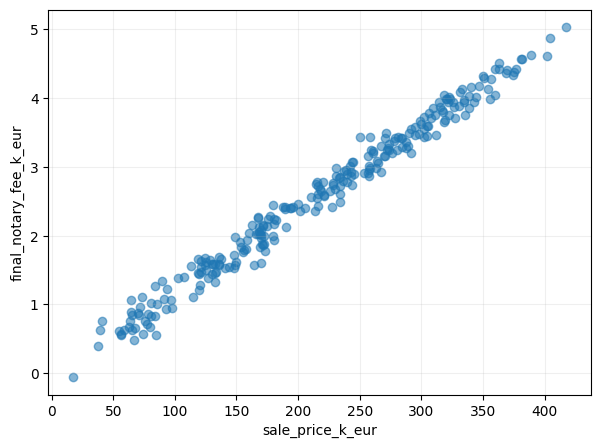

In [5]:
fig, ax = plt.subplots(figsize=(7, 5)) 

ax.scatter(df["sale_price_k_eur"], df["final_notary_fee_k_eur"], alpha=0.55)
ax.set_xlabel("sale_price_k_eur")
ax.set_ylabel("final_notary_fee_k_eur")

ax.grid(alpha=0.2)

plt.show()

Primero, tu dataframe es todo el csv.

Ahora, eliminamos las columnas del leakage con `.drop()`, creando un nuevo data frame `df_model`.

A partir de `df_model` seleccionamos cuál es nuestra X y nuestra y. (Recordar que puede haber varios targets -varias preguntas- para un mismo dataset)

In [6]:
df.head()

,house_id,living_area_m2,usable_area_m2,living_area_ft2,rooms,age_years,distance_center_km,noise_feature,final_notary_fee_k_eur,final_agent_commission_k_eur,final_price_per_m2_k_eur,sale_price_k_eur
0,H0001,181.57,172.04,1954.401323,6,19.0,15.45,0.125730,3.600,9.764,1.6806,305.14
1,H0002,124.61,124.05,1341.289579,4,53.4,6.75,-0.132105,2.891,7.673,1.9242,239.77
2,H0003,195.96,180.25,2109.293844,6,35.6,15.82,0.640423,3.458,9.988,1.5929,312.14
3,H0004,168.55,157.46,1814.255345,6,7.6,8.35,0.104900,3.205,8.355,1.5491,261.10
4,H0005,66.01,65.16,710.525039,2,8.6,24.42,-0.535669,0.762,2.032,0.9621,63.51


We have to delete data leakage columns + house_id + noise_feature 

`noise_feature` is not data leakage as such, because it is avaliable before sale, but it explicitly says that it's useless.

`axis = 1` tells pandas that we are removing columns, not rows (`axis = 0`).

In [7]:
# TODO: complete the list with the identifier and all variables that are unavailable at prediction time.
columns_to_remove = [
    "house_id",
    "noise_feature",
    "final_notary_fee_k_eur",
    "final_agent_commission_k_eur",
    "final_price_per_m2_k_eur"
]

# TODO: remove those columns from df to create the modelling dataframe.
df_model = df.drop(columns_to_remove, axis = 1)

# Check the modelling table before continuing.
display(df_model.head())
print("Columns used from this point onwards:")
print(df_model.columns.tolist())

,living_area_m2,usable_area_m2,living_area_ft2,rooms,age_years,distance_center_km,sale_price_k_eur
0,181.57,172.04,1954.401323,6,19.0,15.45,305.14
1,124.61,124.05,1341.289579,4,53.4,6.75,239.77
2,195.96,180.25,2109.293844,6,35.6,15.82,312.14
3,168.55,157.46,1814.255345,6,7.6,8.35,261.10
4,66.01,65.16,710.525039,2,8.6,24.42,63.51


Columns used from this point onwards:
['living_area_m2', 'usable_area_m2', 'living_area_ft2', 'rooms', 'age_years', 'distance_center_km', 'sale_price_k_eur']


## 3. Simple linear regression

Fit a first regression model using only `living_area_m2` and evaluate it on data that were not used for fitting.

Start with one predictor: `living_area_m2`.

Create train / validation / test sets before fitting the model.

Use 60% / 20% / 20%.

In [8]:
feature_simple = ["living_area_m2"]
target = "sale_price_k_eur"

X = df_model[feature_simple]
y = df_model[target]

# TODO: choose test_size so that 20% of the full dataset is reserved for test.
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

# TODO: choose test_size so that validation is 20% of the original dataset.
# Remember that X_temp contains 80% of the original rows.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25, #0.2/0.8
    random_state=RANDOM_STATE,
)

pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_val), len(X_test)],
})

,split,n
0,train,156
1,validation,52
2,test,52


We can see the train/val/test proportion

In [9]:
pd.DataFrame({
    "split": ["train", "validation", "test"],
    "proportion": [len(X_train)/len(X), len(X_val)/len(X), len(X_test)/len(X)],
})

,split,proportion
0,train,0.6
1,validation,0.2
2,test,0.2


Añadimos `fit_intercept = True` porque queremos calcular $\beta_0$ (aunque por defecto es True). Pondríamos `=False` si sabemos que los datos están centrados.

¡Ojo! A veces es más fácil leer la documentación de la función pasando el cursor sobre ella que preguntarle a una IA cómo se inicia un modelo de regresión lineal.

In [10]:
# TODO: initialize a Linear Regression model from scikit-learn
simple_model = LinearRegression(fit_intercept = True)

# TODO: fit the linear regression model using only the training data.
simple_model.fit(X_train,y_train)

# TODO: generate predictions for train and validation.
train_pred_simple = simple_model.predict(X_train)
val_pred_simple = simple_model.predict(X_val)

pd.DataFrame({
    "quantity": ["intercept", "slope"],
    "value": [simple_model.intercept_, simple_model.coef_[0]],
})

,quantity,value
0,intercept,-19.872967
1,slope,1.758712


El modelo es $$\hat{y}_i = -19.872967 + 1.758712 x_i$$

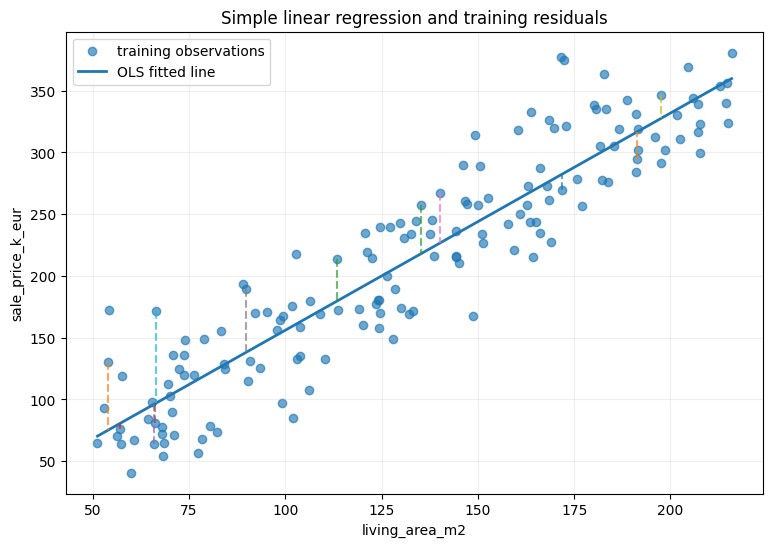

In [11]:
# Visualize the fitted line on the training data.
# Also draw vertical residual segments for 12 observations.

fig, ax = plt.subplots(figsize=(9, 6))

# Scatter of observed training points.
ax.scatter(
    X_train["living_area_m2"],
    y_train,
    alpha=0.65,
    label="training observations",
)

# Fitted line: sort X before plotting.
order = np.argsort(X_train["living_area_m2"].to_numpy())
ax.plot(
    X_train["living_area_m2"].to_numpy()[order],
    train_pred_simple[order],
    linewidth=2,
    label="OLS fitted line",
)

# Residual segments for a small subset.
sample_idx = X_train.index[:12]
for idx in sample_idx:
    x_i = X_train.loc[idx, "living_area_m2"]
    y_i = y_train.loc[idx]
    yhat_i = simple_model.predict(pd.DataFrame({"living_area_m2": [x_i]}))[0]
    ax.plot([x_i, x_i], [y_i, yhat_i], linestyle="--", alpha=0.7)

ax.set_xlabel("living_area_m2")
ax.set_ylabel("sale_price_k_eur")
ax.set_title("Simple linear regression and training residuals")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

Arriba ha dibujado la línea que mi modelo ha predicho. (Tiene buena pinta)

### Interpretation

TODO - Complete the following interpretations.

```text
The fitted slope means that... the sale_price_k_eur increases by a factor of 1.76 for each m^2.

The fitted intercept means that... it doesn't make sense to think about 0m^2 houses, so in this case the intercept is just a variable for the model.

For a point above the fitted line, the residual is positive / negative because... it is positive because the model underestimates that point

The line estimates an individual home's exact price / the mean response for a given living area because... the mean response for a given living area because we are given that variable
```

## 4. Multiple linear regression

Extend the model to several predictors and interpret each coefficient conditionally, holding the other included predictors fixed.

Use these predictors:

- `living_area_m2`
- `rooms`
- `age_years`
- `distance_center_km`

$$\hat{y}_i = -19.872967 + 1.758712 x_i$$

In [12]:
def formula_modelo(x):
    return -19.872967 + 1.758712*x

In [13]:
df_model[feature_simple] #living_area_m2

,living_area_m2
0,181.57
1,124.61
2,195.96
3,168.55
4,66.01
...,...
255,176.82
256,188.82
257,67.90
258,61.32


Esto lo calculamos para tener $\hat{y}$ y deducir RMSE.

In [14]:
y_pred_simple = []

for index, row in df_model[feature_simple].iterrows():
    y_pred_simple.append(float(formula_modelo(row["living_area_m2"])))

y_pred_simple

[299.45637084,
 199.28013532000003,
 324.76423652,
 276.5579406,
 96.21961212000001,
 359.76260532000003,
 295.62237867999994,
 303.07931756,
 106.36738036,
 202.72721084,
 178.93183748000004,
 345.1477086,
 260.57124852,
 314.05368044,
 200.63434356000002,
 136.00167756000002,
 233.87400036000003,
 87.14465820000001,
 315.5134114,
 256.91312755999996,
 294.70784844,
 174.06020524000002,
 358.28528724,
 335.08787596,
 300.79299196,
 126.25841308000001,
 207.59884308000002,
 81.1650374,
 114.19364876000002,
 272.28427044,
 290.73315932,
 357.33558275999997,
 165.47769068000002,
 178.82631476000003,
 208.44302484,
 124.71074652,
 106.91258108000001,
 210.28967244000003,
 135.89615484,
 268.32716844,
 198.77010884,
 317.02590372,
 277.4372966,
 161.4502402,
 316.88520675999996,
 308.67202172,
 183.90899244000002,
 154.27469524,
 272.10839924,
 109.84963012000001,
 127.82366676,
 70.261023,
 303.34312436,
 266.83226324000003,
 278.89702755999997,
 301.47888964,
 205.27734324000005,
 238.11

In [15]:
y

0      305.14
1      239.77
2      312.14
3      261.10
4       63.51
        ...  
255    264.36
256    342.84
257     77.32
258     83.55
259    233.58
Name: sale_price_k_eur, Length: 260, dtype: float64

In [16]:
features_multi = ["living_area_m2", "rooms", "age_years", "distance_center_km"]

X_multi = df_model[features_multi]
y_multi = df_model[target]

# Reuse the same row indices as the simple split.
# Aquí tomas los mismos índices, pero ahora consideras más columnas (antes solo una)
X_train_multi = X_multi.loc[X_train.index]
X_val_multi = X_multi.loc[X_val.index]
X_test_multi = X_multi.loc[X_test.index]
y_train_multi = y_multi.loc[X_train.index]
y_val_multi = y_multi.loc[X_val.index]
y_test_multi = y_multi.loc[X_test.index]

# TODO: initialize a Linear Regression model from scikit-learn
multi_model = LinearRegression()

# TODO: fit the multiple linear regression using the training data.
multi_model.fit(X_train_multi,y_train_multi)

LinearRegression()

In [17]:
print("beta_0 = ", multi_model.intercept_)

i=1
for coef in multi_model.coef_:
    print(f"beta_{i} = ", coef)
    i=i+1

beta_0 =  23.120971316548605
beta_1 =  1.5189492182238675
beta_2 =  7.287467623934722
beta_3 =  -0.6971688922122329
beta_4 =  -1.6717830041959634


El modelo de regresión lineal múltiple es $$\hat{y}_i = 23.120971316548605 + 1.5189492182238675 x_1 + 7.287467623934722 x_2 + -0.6971688922122329 x_3 + -1.6717830041959634 x_4$$

In [18]:
y_pred_multiple = []

for index, row in df_model[features_multi].iterrows():
    y_pred_multiple.append(float(
        23.120971316548605 + 
        1.5189492182238675 * row["living_area_m2"] +  
        7.287467623934722 * row["rooms"]
        - 0.6971688922122329 * row["age_years"]
        - 1.6717830041959634 * row["distance_center_km"]
        ))

y_pred_multiple

[303.56613024620447,
 193.03374977270767,
 313.2322461741704,
 303.6067961259406,
 91.14115102388493,
 355.80874990069043,
 295.88692507184635,
 322.7876798648641,
 95.3126350426157,
 200.41842384844577,
 190.1591775093389,
 328.8149983628562,
 238.12944786923933,
 321.4280572175669,
 191.18274898697373,
 126.94731673659084,
 235.36617675987839,
 77.38775657673065,
 337.83549646063966,
 285.685876856468,
 268.146867172029,
 161.46967420268948,
 337.6154553077542,
 290.22142164861606,
 311.6829709088069,
 106.8680804839741,
 214.26375569906864,
 60.627644114039036,
 123.36201281898869,
 268.3996110918564,
 277.4238606768991,
 370.63602037224825,
 165.28909829531185,
 161.4247146097012,
 208.1364941226686,
 128.33835641829197,
 71.80915730967962,
 197.4099926869479,
 150.2672680277393,
 306.8436871591656,
 193.17055211746126,
 302.5614884620122,
 271.33575447333504,
 191.17965690452272,
 287.91573942983445,
 321.22327274322043,
 175.58195850103934,
 140.0833165082621,
 262.78090628319995

He calculado `y_pred_simple` y `y_pred_multiple` a lo bruto. No creo que sea la mejor opción.

In [19]:
# TODO: generate train and validation predictions.
train_pred_multi = multi_model.predict(X_train_multi)
val_pred_multi = multi_model.predict(X_val_multi)

coef_table = pd.DataFrame({
    "predictor": features_multi,
    "coefficient": multi_model.coef_,
})

display(coef_table)


#from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score <-- funciones para calcular lo de abajo

# TODO: compare validation performance of simple and multiple regression. Use the metrics from scikit-learn.
comparison = pd.DataFrame({
    "model": ["simple", "multiple"],
    "validation_RMSE": [
        mean_squared_error(y_true=y, y_pred = y_pred_simple) ** 0.5, #simple
        mean_squared_error(y_true=y, y_pred = y_pred_multiple) ** 0.5, #multiple
    ],
    "validation_MAE": [
        mean_absolute_error(y_true=y, y_pred = y_pred_simple), #simple
        mean_absolute_error(y_true=y, y_pred = y_pred_multiple), #multiple
    ],
    "validation_R2": [
        r2_score(y_true=y, y_pred = y_pred_simple), #simple
        r2_score(y_true=y, y_pred = y_pred_multiple), #multiple
    ],
})
comparison

,predictor,coefficient
0,living_area_m2,1.518949
1,rooms,7.287468
2,age_years,-0.697169
3,distance_center_km,-1.671783


,model,validation_RMSE,validation_MAE,validation_R2
0,simple,33.660974,27.316142,0.869954
1,multiple,27.985926,22.100725,0.910108


y_pred lo puedo sustituir por val_pred, para no calcularlo a lo bruto

In [20]:
# Make two controlled predictions.
# The second home should differ only in living area.

home_A = pd.DataFrame([{
    "living_area_m2": 100,
    "rooms": 3,
    "age_years": 10,
    "distance_center_km": 8,
}])


# TODO: make home B like home A, but 10 m² larger than home A.
home_B = pd.DataFrame([{
    "living_area_m2": 110,
    "rooms": 3,
    "age_years": 10,
    "distance_center_km": 8,
}])

# TODO: predict the sale price for both homes.
pred_A = multi_model.predict(home_A)[0]
pred_B = multi_model.predict(home_B)[0]

print("Prediction A:", pred_A)
print("Prediction B:", pred_B)
print("Difference B - A:", pred_B - pred_A)

Prediction A: 176.5323430550495
Prediction B: 191.72183523728816
Difference B - A: 15.189492182238666


### Interpretation

TODO - Complete the following interpretations.

```text
The coefficient of living_area_m2 means that... in multiple linnear regression, the increasing factor is slightly lower, because the model gives more weight to other variables.

The coefficient of age_years means that... the more years a house has, the cheaper it is. We can deduce it from the negative coefficient.

The difference between home B and home A equals approximately... 15k eur (remember the price increases 1.5 with m^2)

The phrase “holding the other included predictors fixed” matters because... we have to interpret each one individually
```

## 5. Correlated predictors and coefficient stability

Investigate what happens to regression coefficients when predictors contain very similar information.

The dataset contains two situations from the theory:

```text
Strong correlation       predictors contain very similar, but not identical, information.
Exact linear dependence  one predictor can be calculated exactly from another.
```

Stable prediction does not guarantee stable coefficient interpretation.

,living_area_m2,usable_area_m2,living_area_ft2,rooms,age_years,distance_center_km
living_area_m2,1.000,0.996,1.000,0.928,-0.038,-0.052
usable_area_m2,0.996,1.000,0.996,0.925,-0.028,-0.051
living_area_ft2,1.000,0.996,1.000,0.928,-0.038,-0.052
rooms,0.928,0.925,0.928,1.000,-0.029,-0.071
age_years,-0.038,-0.028,-0.038,-0.029,1.000,-0.027
distance_center_km,-0.052,-0.051,-0.052,-0.071,-0.027,1.000


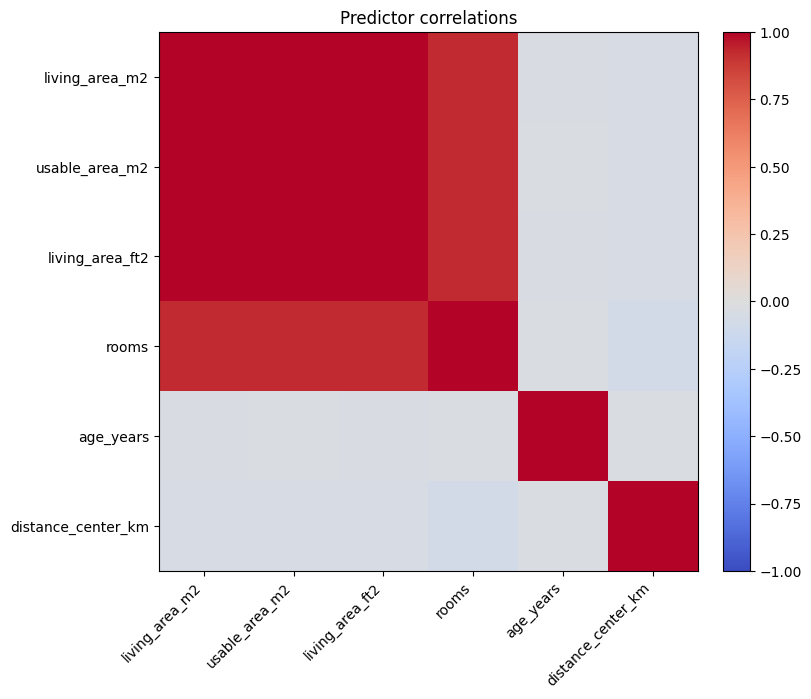

In [21]:
correlation_features = [
    "living_area_m2",
    "usable_area_m2",
    "living_area_ft2",
    "rooms",
    "age_years",
    "distance_center_km",
]

# correlation matrix for the selected predictors.
corr = df_model[correlation_features].corr()
display(corr.round(3))

# Visualize the correlation matrix with imshow.
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(correlation_features)))
ax.set_yticks(range(len(correlation_features)))
ax.set_xticklabels(correlation_features, rotation=45, ha="right")
ax.set_yticklabels(correlation_features)
ax.set_title("Predictor correlations")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

Si la correlación es +1, significa que "cuando una sube, la otra también". Si es -1 significa "cuando una sube, la otra baja".

Coefficient variability


,coef_living_area,coef_usable_area
model,,
correlated,0.528567,0.567886
stable,0.048701,NaN


Prediction variability


seed                     57.879185
stable_prediction         3.119186
correlated_prediction     3.138968
dtype: float64

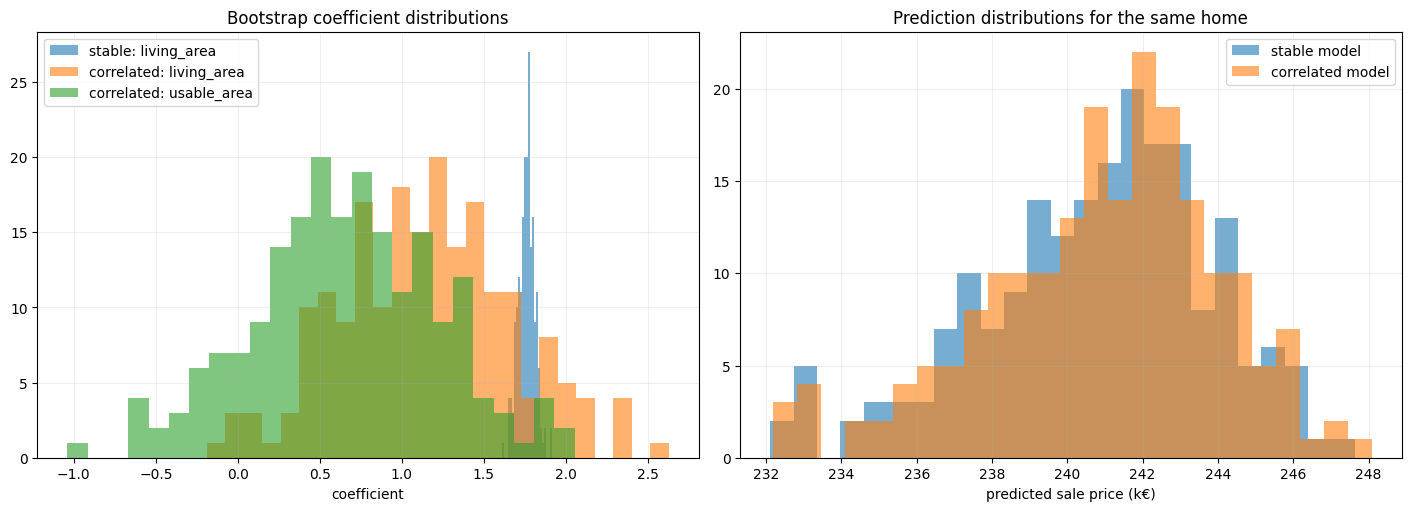

In [22]:
# Strong correlation: compare coefficient stability across bootstrap resamples.

features_stable = ["living_area_m2", "age_years", "distance_center_km"]
features_correlated = ["living_area_m2", "usable_area_m2", "age_years", "distance_center_km"]

bootstrap_rows = []
prediction_rows = []

reference_home = pd.DataFrame([{
    "living_area_m2": 140,
    "usable_area_m2": 132,
    "age_years": 20,
    "distance_center_km": 8,
}])

for seed in range(200):
    sample = df.loc[X_train.index].sample(n=len(X_train), replace=True, random_state=seed)

    stable_model = LinearRegression()
    correlated_model = LinearRegression()

    # TODO: fit one model without usable_area_m2 and one model including it.
    stable_model.fit(sample[features_stable], sample[target])
    correlated_model.fit(sample[features_correlated], sample[target])

    bootstrap_rows.append({
        "seed": seed,
        "model": "stable",
        "coef_living_area": stable_model.coef_[0],
        "coef_usable_area": np.nan,
    })
    bootstrap_rows.append({
        "seed": seed,
        "model": "correlated",
        "coef_living_area": correlated_model.coef_[0],
        "coef_usable_area": correlated_model.coef_[1],
    })

    # TODO: predict the same reference home with both models.
    stable_prediction = stable_model.predict(reference_home[features_stable])[0]
    correlated_prediction = correlated_model.predict(reference_home[features_correlated])[0]

    prediction_rows.append({
        "seed": seed,
        "stable_prediction": stable_prediction,
        "correlated_prediction": correlated_prediction,
    })

bootstrap_df = pd.DataFrame(bootstrap_rows)
prediction_df = pd.DataFrame(prediction_rows)

print("Coefficient variability")
display(bootstrap_df.groupby("model")[["coef_living_area", "coef_usable_area"]].std())
print("Prediction variability")
display(prediction_df.std())

# Visualize coefficient distributions and prediction distributions.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].hist(
    bootstrap_df.loc[bootstrap_df["model"] == "stable", "coef_living_area"],
    bins=25,
    alpha=0.6,
    label="stable: living_area",
)
axes[0].hist(
    bootstrap_df.loc[bootstrap_df["model"] == "correlated", "coef_living_area"],
    bins=25,
    alpha=0.6,
    label="correlated: living_area",
)
axes[0].hist(
    bootstrap_df.loc[bootstrap_df["model"] == "correlated", "coef_usable_area"].dropna(),
    bins=25,
    alpha=0.6,
    label="correlated: usable_area",
)
axes[0].set_title("Bootstrap coefficient distributions")
axes[0].set_xlabel("coefficient")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].hist(prediction_df["stable_prediction"], bins=25, alpha=0.6, label="stable model")
axes[1].hist(prediction_df["correlated_prediction"], bins=25, alpha=0.6, label="correlated model")
axes[1].set_title("Prediction distributions for the same home")
axes[1].set_xlabel("predicted sale price (k€)")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.show()

Si solo añadimos una variable correlacionada, sabemos que el valor del coeficiente de living_area se mueve entre 1.5, 2. 

### Interpretation

TODO - Complete the following interpretations.

```text
The strongest non-exact correlation is between... living_area and usable_area

With strongly correlated predictors, individual coefficients are / are not stable across bootstrap samples because...

Predictions can remain comparatively stable because...

With exact linear dependence, unique individual coefficients are / are not identified because...

```

## 6. Goodness of fit: R²

Although R² provides a relative comparison with the mean baseline, it does not express prediction errors in the units of Y. When using it, we must first inspect the data and the residuals.

In this section, we will create 3 new datasets and plot them along their fitted line using linear regression for interpretation.

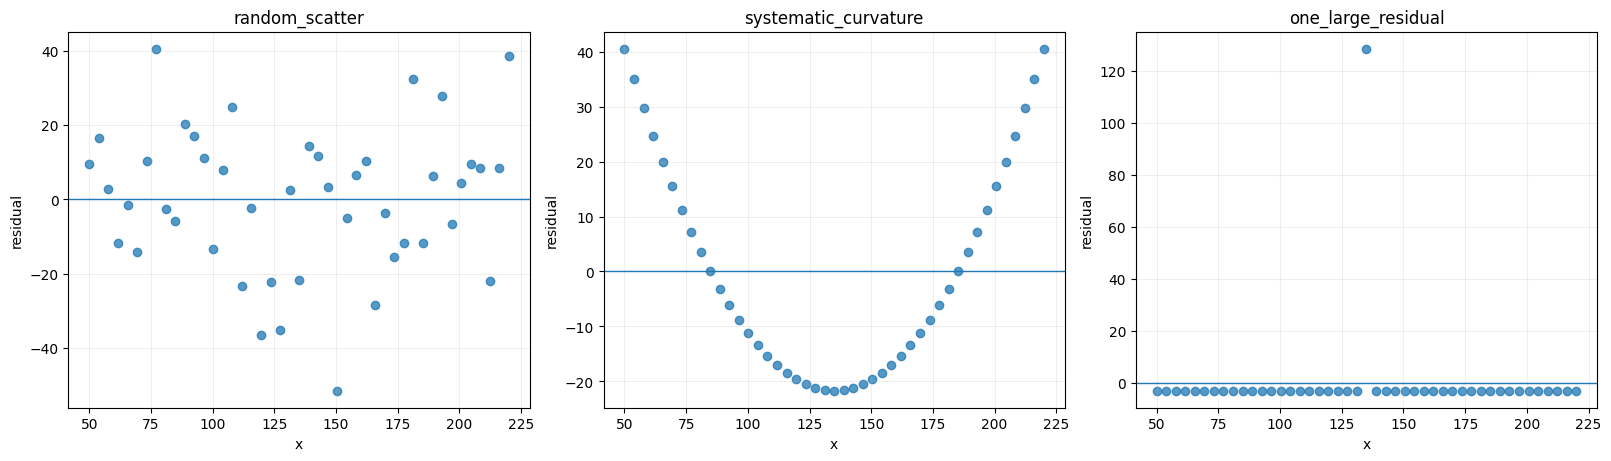

,pattern,R2,RSS
0,random_scatter,0.964051,16900.0
1,systematic_curvature,0.964051,16900.0
2,one_large_residual,0.964051,16900.0


In [23]:
# Same fitted line and same R2, different residual patterns.
# The residual vectors below are constructed to be orthogonal to [1, x]
# and scaled to the same norm. Do not modify the construction.

rng_patterns = np.random.default_rng(7)
x_pattern = np.linspace(50, 220, 45)
X_design = np.column_stack([np.ones_like(x_pattern), x_pattern])
projection = X_design @ np.linalg.pinv(X_design)
residual_projector = np.eye(len(x_pattern)) - projection

raw_patterns = {
    "random_scatter": rng_patterns.normal(size=len(x_pattern)),
    "systematic_curvature": (x_pattern - x_pattern.mean()) ** 2,
    "one_large_residual": np.eye(1, len(x_pattern), len(x_pattern) // 2).ravel() * 10,
}

pattern_frames = []
for name, raw in raw_patterns.items():
    e = residual_projector @ raw
    e = e / np.linalg.norm(e) * 130
    y_pattern = 20 + 2 * x_pattern + e
    pattern_frames.append(pd.DataFrame({"pattern": name, "x": x_pattern, "y": y_pattern}))

patterns_df = pd.concat(pattern_frames, ignore_index=True)

# Fit one OLS line for each pattern, calculate R2, and make residual plots.
pattern_results = []
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

for ax, (name, group) in zip(axes, patterns_df.groupby("pattern", sort=False)):
    model = LinearRegression()
    model.fit(group[["x"]], group["y"])
    pred = model.predict(group[["x"]])
    resid = group["y"].to_numpy() - pred
    pattern_results.append({
        "pattern": name,
        "R2": r2_score(group["y"], pred),
        "RSS": np.sum(resid ** 2),
    })

    ax.scatter(group["x"], resid, alpha=0.75)
    ax.axhline(0, linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("residual")
    ax.grid(alpha=0.2)

plt.show()
pd.DataFrame(pattern_results)

### Interpretation

TODO - Complete the following interpretations.

```text
An R2 of 0.75 does not mean 75% accuracy because... it means that the model is 75% better than just the mean

The three pattern datasets show why R2 alone... is not a good metric
```

## 7. Adding predictors and adjusted R²

Adding more variables can make the training R² appear better, even when those variables do not provide useful information.

Adjusted R² requires the reduction in RSS to be sufficiently large relative to the number of predictors.

That is why we compare three models:

+ area_only: uses only living_area_m2.

+ useful_predictors: adds variables that are relevant for explaining the sale price.

+ useful_plus_noise: also adds noise_feature, which is random noise and should not provide meaningful predictive information.

,model,p,train_R2,train_adjusted_R2,validation_RMSE
0,area_only,1,0.854637,0.853693,32.439871
1,useful_predictors,4,0.894560,0.891767,25.837809
2,useful_plus_noise,5,0.894867,0.891362,25.875597


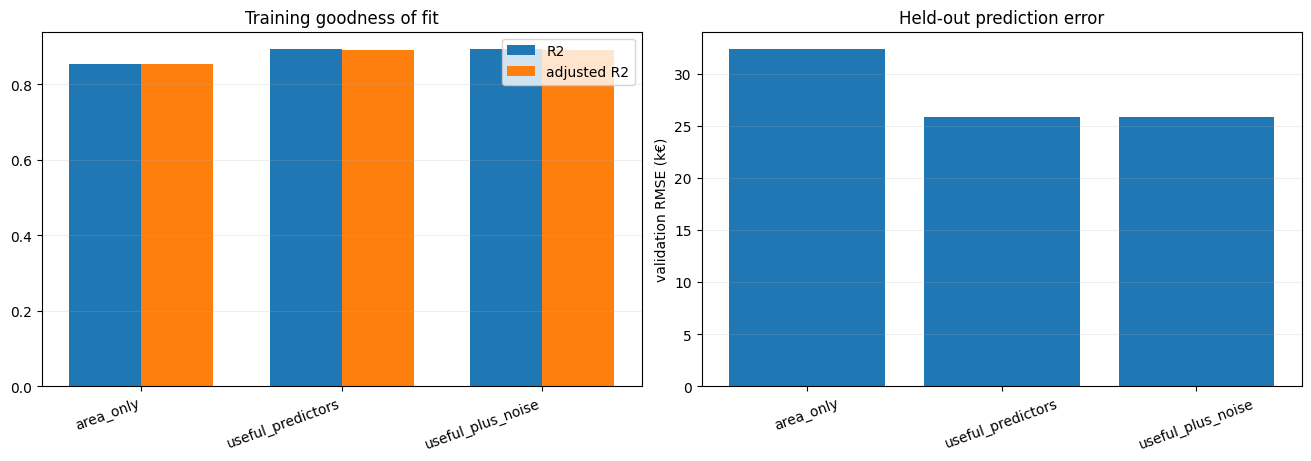

In [24]:
model_specs = {
    "area_only": ["living_area_m2"],
    "useful_predictors": ["living_area_m2", "rooms", "age_years", "distance_center_km"],
    "useful_plus_noise": ["living_area_m2", "rooms", "age_years", "distance_center_km", "noise_feature"],
}

results = []

for name, features in model_specs.items():
    model = LinearRegression()
    Xtr = df.loc[X_train.index, features]
    Xva = df.loc[X_val.index, features]
    model.fit(Xtr, y_train)
    train_pred = model.predict(Xtr)
    val_pred = model.predict(Xva)

    n_train = len(y_train)
    p = len(features)
    # R2.
    train_r2 = r2_score(y_train, train_pred)

    # Adjusted R2.
    adjusted_r2 = 1 - (1 - train_r2) * (n_train - 1) / (n_train - p - 1)

    results.append({
        "model": name,
        "p": p,
        "train_R2": train_r2,
        "train_adjusted_R2": adjusted_r2,
        "validation_RMSE": mean_squared_error(y_val, val_pred) ** 0.5,
    })

model_comparison_df = pd.DataFrame(results)
display(model_comparison_df)

# Visualize train R2 / adjusted R2 and validation RMSE.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

xpos = np.arange(len(model_comparison_df))
width = 0.36
axes[0].bar(xpos - width/2, model_comparison_df["train_R2"], width=width, label="R2")
axes[0].bar(xpos + width/2, model_comparison_df["train_adjusted_R2"], width=width, label="adjusted R2")
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(model_comparison_df["model"], rotation=20, ha="right")
axes[0].set_title("Training goodness of fit")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(model_comparison_df["model"], model_comparison_df["validation_RMSE"])
axes[1].set_ylabel("validation RMSE (k€)")
axes[1].set_title("Held-out prediction error")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.2)

plt.show()

### Interpretation

TODO - Complete the following interpretations.

```text
Training R2 changes when predictors are added because... it makes the y_pred change, and therefore the SSR (Sum of Squared Residuals)

Adjusted R2 can decrease when...

There is / is not a universal acceptable value of R2 because...
```

El R2 no te dice nada de la predicción, solo te dice del entrenamiento. "Cuánto es mejor que la media".

## 8. Error metrics: MSE, RMSE, MAE

Compute and compare common regression error metrics, and observe how they react to one unusually large prediction error.

In [25]:
# Compute MSE, RMSE and MAE on the simple model validation predictions.

validation_errors = y_val.to_numpy() - val_pred_simple

# TODO: compute the three validation metrics.
mse_simple = mean_squared_error(y_true=y, y_pred = y_pred_simple)
rmse_simple = mean_squared_error(y_true=y, y_pred = y_pred_simple) ** 0.5
mae_simple = mean_absolute_error(y_true=y, y_pred = y_pred_simple)

pd.Series({
    "MSE": mse_simple,
    "RMSE": rmse_simple,
    "MAE": mae_simple,
})

MSE     1133.061142
RMSE      33.660974
MAE       27.316142
dtype: float64

,predictions,MSE,RMSE,MAE
0,regular,50.000000,7.071068,7.000000
1,one_large_error,979.333333,31.294302,18.333333


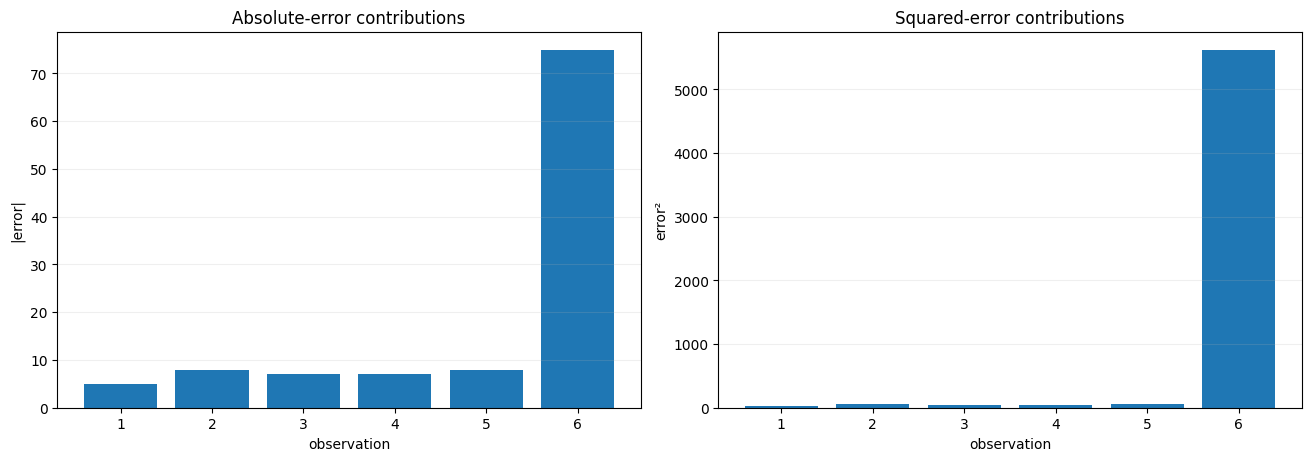

In [26]:
# What does one large error do to squared and absolute error?

y_demo = np.array([100, 120, 140, 160, 180, 200], dtype=float)
pred_regular = np.array([105, 112, 147, 153, 188, 193], dtype=float)
pred_large_error = pred_regular.copy()
pred_large_error[-1] = 275

# Calculate errors and per-observation contributions.
regular_errors = y_demo - pred_regular
large_errors = y_demo - pred_large_error

metric_demo = pd.DataFrame({
    "predictions": ["regular", "one_large_error"],
    "MSE": [np.mean(regular_errors ** 2), np.mean(large_errors ** 2)],
    "RMSE": [np.sqrt(np.mean(regular_errors ** 2)), np.sqrt(np.mean(large_errors ** 2))],
    "MAE": [np.mean(np.abs(regular_errors)), np.mean(np.abs(large_errors))],
})
display(metric_demo)

# Visualize absolute-error and squared-error contributions for the large-error case.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
obs = np.arange(1, len(y_demo) + 1)
axes[0].bar(obs, np.abs(large_errors))
axes[0].set_title("Absolute-error contributions")
axes[0].set_xlabel("observation")
axes[0].set_ylabel("|error|")
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(obs, large_errors ** 2)
axes[1].set_title("Squared-error contributions")
axes[1].set_xlabel("observation")
axes[1].set_ylabel("error²")
axes[1].grid(axis="y", alpha=0.2)

plt.show()

### Interpretation

TODO - Complete the following interpretations.

```text
RMSE and MAE are both in the units of... the target, here k€

MSE is in the units of... squared target unit, (k€)^2

A large error has more relative influence on MSE/RMSE because... the errors are squared (^2). In MAE not.

```